# ALD Showerhead — MultiHead MeshGraphNet Retraining
**83 reactingFoam cases  ·  Colab A100  ·  hidden=256 / 15 layers**

Produces `multihead_final.pt` in the same format `app.py` expects.

**Before running:**
1. Runtime → Change runtime type → **A100 GPU**
2. Upload `data/processed/ald_hdf5/` from your Mac to  
   `MyDrive/cfd-ald-app/ald_hdf5/` (drag-drop in Drive, ~317 MB)
3. Run cells top-to-bottom


In [1]:
import torch, subprocess, sys

assert torch.cuda.is_available(), "Switch runtime to A100 GPU first!"
print(f"GPU : {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

TORCH_VER = torch.__version__.split('+')[0]   # e.g. '2.3.0'
CUDA_VER  = torch.version.cuda.replace('.','') # e.g. '121'

# torch_geometric wheels must match the installed torch+cuda
install_cmd = (
    f"pip install -q torch-geometric "
    f"torch-scatter torch-sparse torch-cluster "
    f"-f https://data.pyg.org/whl/torch-{TORCH_VER}+cu{CUDA_VER}.html"
)
print("Installing torch_geometric …")
subprocess.run(install_cmd, shell=True, check=True)
print("Done.")


GPU : NVIDIA A100-SXM4-80GB
VRAM: 85.1 GB
Installing torch_geometric …
Done.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

DRIVE_BASE = Path('/content/drive/MyDrive/cfd-ald-app')
HDF5_DIR   = DRIVE_BASE / 'ald_hdf5'
CKPT_DIR   = DRIVE_BASE / 'checkpoints' / 'multihead'
CKPT_DIR.mkdir(parents=True, exist_ok=True)

assert HDF5_DIR.exists(), f"HDF5 folder not found: {HDF5_DIR}"
h5_all = sorted(HDF5_DIR.glob('*.h5'))
print(f"Found {len(h5_all)} HDF5 files")

# ── Hyper-parameters ──────────────────────────────────────────────────────────
CFG = dict(
    hidden_dim      = 256,
    n_layers        = 15,
    k_neighbors     = 6,
    node_input_dim  = 22,   # 4 node features + 18 global features
    edge_input_dim  = 4,    # rel_x, rel_y, rel_z, dist  (median-normalised)
    flow_out_dim    = 4,    # Ux, Uy, Uz, p
    heat_out_dim    = 1,    # T
    species_out_dim = 1,    # TMA
    lr              = 3e-4,
    weight_decay    = 1e-4,
    epochs          = 200,
    save_every      = 20,
    n_train_nodes   = 16_384,   # subsample per case per step (memory-efficient)
    n_val_nodes     = 50_000,   # subsample for validation (set None for full graph)
)

DEVICE = torch.device('cuda')
OUTPUT_COLS = ['Ux', 'Uy', 'Uz', 'p', 'T', 'TMA']
print(f"Config: hidden={CFG['hidden_dim']}, layers={CFG['n_layers']}, k={CFG['k_neighbors']}")


Mounted at /content/drive
Found 83 HDF5 files
Config: hidden=256, layers=15, k=6


In [3]:
import numpy as np
import h5py, time
import torch
import torch.nn as nn
from torch_geometric.nn import MessagePassing
from scipy.spatial import cKDTree
from tqdm.notebook import tqdm, trange
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')


In [32]:
def mlp(in_dim, out_dim, hidden=None, n_layers=2):
    hidden = hidden or out_dim
    dims = [in_dim] + [hidden] * (n_layers - 1) + [out_dim]
    mods = []
    for i in range(len(dims) - 1):
        mods.append(nn.Linear(dims[i], dims[i+1]))
        if i < len(dims) - 2:
            mods += [nn.SiLU(), nn.LayerNorm(dims[i+1])]
    return nn.Sequential(*mods)



class MGNProcessor(MessagePassing):
      def __init__(self, hidden):
          super().__init__(aggr='sum')
          self.edge_mlp  = mlp(3 * hidden, hidden)
          self.node_mlp  = mlp(2 * hidden, hidden)
          self.edge_norm = nn.LayerNorm(hidden)
          self.node_norm = nn.LayerNorm(hidden)

      def forward(self, x, edge_index, edge_attr):
          row, col = edge_index
          e_in      = torch.cat([x[row], x[col], edge_attr], dim=-1)
          edge_attr = self.edge_norm(self.edge_mlp(e_in) + edge_attr)
          N   = x.size(0)
          agg = self.propagate(edge_index, x=x, edge_attr=edge_attr,
                               size=(N, N))          # ← fixes the size mismatch
          x   = self.node_norm(self.node_mlp(torch.cat([x, agg], dim=-1)) + x)
          return x, edge_attr

      def message(self, edge_attr):
          return edge_attr


class MultiHeadMGN(nn.Module):
    def __init__(self, node_dim, edge_dim,
                 flow_out=4, heat_out=1, species_out=1,
                 hidden=256, n_layers=15):
        super().__init__()
        self.node_enc    = mlp(node_dim, hidden)
        self.edge_enc    = mlp(edge_dim, hidden)
        self.processors  = nn.ModuleList([MGNProcessor(hidden) for _ in range(n_layers)])
        self.flow_dec    = mlp(hidden, flow_out)
        self.heat_dec    = mlp(hidden, heat_out)
        self.species_dec = mlp(hidden, species_out)

    def forward(self, x, edge_index, edge_attr):
        x  = self.node_enc(x)
        ea = self.edge_enc(edge_attr)
        for proc in self.processors:
            x, ea = proc(x, edge_index, ea)
        return self.flow_dec(x), self.heat_dec(x), self.species_dec(x)


model = MultiHeadMGN(
    node_dim    = CFG['node_input_dim'],
    edge_dim    = CFG['edge_input_dim'],
    flow_out    = CFG['flow_out_dim'],
    heat_out    = CFG['heat_out_dim'],
    species_out = CFG['species_out_dim'],
    hidden      = CFG['hidden_dim'],
    n_layers    = CFG['n_layers'],
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f"MultiHeadMGN  params: {n_params/1e6:.1f}M")


MultiHeadMGN  params: 7.1M


In [33]:
def load_case(h5_path):
    """Load one HDF5 case. Returns dict with numpy arrays."""
    with h5py.File(h5_path, 'r') as h:
        coords = h['coords'][:]                     # [N, 3]
        nf     = h['inputs/node_features'][:]       # [N, 4]
        gf     = h['inputs/global'][:]              # [18]
        y      = h['outputs/node_fields'][:]        # [N, 6]
    N = min(len(coords), len(nf), len(y))
    # Broadcast global features to all nodes
    xi = np.concatenate([nf[:N], np.tile(gf, (N, 1))], axis=1)  # [N, 22]
    return {'coords': coords[:N], 'x': xi, 'y': y[:N], 'path': str(h5_path)}


def build_graph_tensors(case, n_nodes=None, k=6, device='cpu'):
    """Build k-NN graph tensors from a loaded case dict.
    Optionally subsamples n_nodes (for memory efficiency during training)."""
    coords = case['coords']
    x      = case['x']
    y      = case['y']
    N_full = len(coords)

    if n_nodes is not None and n_nodes < N_full:
        idx    = np.random.choice(N_full, n_nodes, replace=False)
        coords = coords[idx];  x = x[idx];  y = y[idx]

    N = len(coords)
    # k-NN edges
    tree     = cKDTree(coords)
    _, nbrs  = tree.query(coords, k=k + 1)
    nbrs     = nbrs[:, 1:]                        # exclude self
    src      = np.repeat(np.arange(N), k)
    dst      = nbrs.flatten()

    diff = coords[dst] - coords[src]              # [E, 3]
    dist = np.linalg.norm(diff, axis=1, keepdims=True)  # [E, 1]
    med  = float(np.median(dist)) + 1e-8
    ef   = np.concatenate([diff / med, dist / med], axis=1).astype(np.float32)

    return {
        'x'          : torch.tensor(x,   dtype=torch.float32).to(device),
        'edge_index' : torch.tensor(np.stack([src, dst]), dtype=torch.long).to(device),
        'edge_attr'  : torch.tensor(ef,  dtype=torch.float32).to(device),
        'y'          : torch.tensor(y,   dtype=torch.float32).to(device),
    }


# ── Train / val split ─────────────────────────────────────────────────────────
val_files   = sorted(HDF5_DIR.glob('cfd_val_*.h5'))
train_files = sorted(HDF5_DIR.glob('case_*.h5'))
print(f"Train: {len(train_files)} cases   Val: {len(val_files)} cases")

# Pre-load all cases into CPU RAM (317 MB total — fits easily)
print("Pre-loading cases into RAM …")
train_cases = [load_case(f) for f in tqdm(train_files)]
val_cases   = [load_case(f) for f in val_files]
print(f"Done. Train nodes/case ≈ {np.mean([len(c['coords']) for c in train_cases]):.0f}")


Train: 80 cases   Val: 3 cases
Pre-loading cases into RAM …


  0%|          | 0/80 [00:00<?, ?it/s]

Done. Train nodes/case ≈ 189661


In [34]:
# Compute per-feature mean + std across all training data
all_x = np.concatenate([c['x'] for c in train_cases], axis=0)
all_y = np.concatenate([c['y'] for c in train_cases], axis=0)

node_mean = all_x.mean(axis=0).astype(np.float32)
node_std  = (all_x.std(axis=0) + 1e-8).astype(np.float32)
out_mean  = all_y.mean(axis=0).astype(np.float32)
out_std   = (all_y.std(axis=0) + 1e-8).astype(np.float32)

NORM = {
    'node_mean'  : node_mean.tolist(),
    'node_std'   : node_std.tolist(),
    'out_mean'   : out_mean.tolist(),
    'out_std'    : out_std.tolist(),
    'output_cols': OUTPUT_COLS,
}

print("Node feature normalisation (22 dims):")
for i, (m, s) in enumerate(zip(node_mean, node_std)):
    print(f"  dim {i:2d}: mean={m:.3e}  std={s:.3e}")
print("\nOutput field normalisation (6 fields):")
for col, m, s in zip(OUTPUT_COLS, out_mean, out_std):
    print(f"  {col}: mean={m:.3e}  std={s:.3e}")

del all_x  # free RAM


Node feature normalisation (22 dims):
  dim  0: mean=7.025e-01  std=2.365e-01
  dim  1: mean=6.164e-01  std=1.228e-01
  dim  2: mean=2.000e+00  std=1.000e-08
  dim  3: mean=0.000e+00  std=1.000e-08
  dim  4: mean=2.453e+00  std=2.897e+00
  dim  5: mean=6.028e-01  std=6.412e-02
  dim  6: mean=6.251e-01  std=8.842e-02
  dim  7: mean=6.056e-05  std=6.280e-05
  dim  8: mean=1.663e+00  std=1.950e+00
  dim  9: mean=1.730e+00  std=2.087e+00
  dim 10: mean=3.556e-01  std=4.204e-01
  dim 11: mean=1.935e-03  std=7.005e-04
  dim 12: mean=4.516e+00  std=1.078e+00
  dim 13: mean=1.860e-02  std=1.382e-03
  dim 14: mean=3.552e-03  std=5.328e-04
  dim 15: mean=1.860e-02  std=1.382e-03
  dim 16: mean=3.659e+00  std=3.523e+00
  dim 17: mean=5.716e-02  std=7.533e-03
  dim 18: mean=1.300e+02  std=1.526e+01
  dim 19: mean=2.833e-05  std=3.645e-06
  dim 20: mean=2.265e+03  std=2.154e+03
  dim 21: mean=6.360e-02  std=2.867e-02

Output field normalisation (6 fields):
  Ux: mean=-1.870e-08  std=2.565e-05
  Uy:

In [35]:
def normalise_y(y_raw):
    """Normalise output fields using training stats. Returns [N, 6] normalised."""
    om = torch.tensor(out_mean, device=y_raw.device)
    os = torch.tensor(out_std,  device=y_raw.device)
    return (y_raw - om) / os


def compute_loss(fp, hp, sp, y_norm):
    """MSE per head, then weighted sum."""
    flow_loss    = nn.functional.mse_loss(fp, y_norm[:, :4])
    heat_loss    = nn.functional.mse_loss(hp.squeeze(-1), y_norm[:, 4])
    species_loss = nn.functional.mse_loss(sp.squeeze(-1), y_norm[:, 5])
    total = flow_loss + heat_loss + species_loss
    return total, {'flow': flow_loss.item(), 'heat': heat_loss.item(), 'species': species_loss.item()}


@torch.no_grad()
def evaluate(cases, n_nodes=None):
    model.eval()
    losses = []
    for case in cases:
        g       = build_graph_tensors(case, n_nodes=n_nodes, k=CFG['k_neighbors'], device=DEVICE)
        y_norm  = normalise_y(g['y'])
        fp, hp, sp = model(g['x'], g['edge_index'], g['edge_attr'])
        loss, _ = compute_loss(fp, hp, sp, y_norm)
        losses.append(loss.item())
    model.train()
    return float(np.mean(losses))


In [36]:
optimizer = torch.optim.AdamW(
      model.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay']
  )
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
      optimizer, T_max=CFG['epochs'], eta_min=CFG['lr'] * 0.01
  )
scaler = torch.cuda.amp.GradScaler()

start_epoch = 0
train_losses, val_losses = [], []
head_logs = {'flow': [], 'heat': [], 'species': []}

print("Training from scratch on 83 cases.")
print("Epochs =", CFG['epochs'])

#Also delete the old checkpoints from Drive so they don't interfere later:

import os
for old in CKPT_DIR.glob('*.pt'):
      os.remove(old)
      print("Removed:", old.name)


Training from scratch on 83 cases.
Epochs = 200


In [37]:
K      = CFG['k_neighbors']
NTRAIN = CFG['n_train_nodes']
NVAL   = CFG['n_val_nodes']

model.train()
pbar = trange(start_epoch, CFG['epochs'], desc='Epoch')

for epoch in pbar:
    ep_loss  = 0.0
    ep_heads = {'flow': 0.0, 'heat': 0.0, 'species': 0.0}
    t0 = time.time()

    # Shuffle train cases each epoch
    order = np.random.permutation(len(train_cases))
    optimizer.zero_grad()

    for step, idx in enumerate(order):
        case  = train_cases[idx]
        g     = build_graph_tensors(case, n_nodes=NTRAIN, k=K, device=DEVICE)
        y_norm = normalise_y(g['y'])

        with torch.cuda.amp.autocast():
            fp, hp, sp = model(g['x'], g['edge_index'], g['edge_attr'])
            loss, heads = compute_loss(fp, hp, sp, y_norm)
            loss = loss / len(order)   # normalise for gradient accumulation

        scaler.scale(loss).backward()
        ep_loss += loss.item() * len(order)
        for k_head in heads:
            ep_heads[k_head] += heads[k_head] / len(order)

        # Step every case (effective batch = all 80 cases, but accumulate grads)
        # For faster updates, step every 8 cases
        if (step + 1) % 8 == 0 or (step + 1) == len(order):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

    scheduler.step()
    train_losses.append(ep_loss)
    for k_head in ep_heads:
        head_logs[k_head].append(ep_heads[k_head])

    # ── Validation ────────────────────────────────────────────────────────────
    val_loss = evaluate(val_cases, n_nodes=NVAL)
    val_losses.append(val_loss)
    dt = time.time() - t0

    pbar.set_postfix({
        'tr': f'{ep_loss:.4f}',
        'val': f'{val_loss:.4f}',
        'lr': f'{scheduler.get_last_lr()[0]:.2e}',
        's': f'{dt:.0f}s',
    })

    # ── Checkpoint ────────────────────────────────────────────────────────────
    if (epoch + 1) % CFG['save_every'] == 0:
        ck_path = CKPT_DIR / f'multihead_epoch{epoch+1:04d}.pt'
        torch.save({
            'model'       : model.state_dict(),
            'cfg'         : CFG,
            'norm'        : NORM,
            'epoch'       : epoch,
            'train_losses': train_losses,
            'val_losses'  : val_losses,
            'head_logs'   : head_logs,
        }, ck_path)
        print(f"  Saved {ck_path.name}")

print("Training complete.")


Epoch:   0%|          | 0/200 [00:00<?, ?it/s]

  Saved multihead_epoch0020.pt
  Saved multihead_epoch0040.pt
  Saved multihead_epoch0060.pt
  Saved multihead_epoch0080.pt
  Saved multihead_epoch0100.pt
  Saved multihead_epoch0120.pt
  Saved multihead_epoch0140.pt
  Saved multihead_epoch0160.pt
  Saved multihead_epoch0180.pt
  Saved multihead_epoch0200.pt
Training complete.


In [38]:
final_path = CKPT_DIR / 'multihead_final.pt'
torch.save({
    'model'            : model.state_dict(),
    'cfg'              : CFG,
    'norm'             : NORM,
    'final_train_loss' : train_losses[-1],
    'final_val_loss'   : val_losses[-1],
    'per_head_train'   : {k: head_logs[k][-1] for k in head_logs},
    'n_cases'          : len(train_cases),
    'data_source'      : 'reactingFoam_openfoam_80cases',
}, final_path)

print(f"Saved: {final_path}")
print(f"Final train loss: {train_losses[-1]:.4f}")
print(f"Final val loss:   {val_losses[-1]:.4f}")
for k in head_logs:
    print(f"  {k:8s} head (last): {head_logs[k][-1]:.4f}")


Saved: /content/drive/MyDrive/cfd-ald-app/checkpoints/multihead/multihead_final.pt
Final train loss: 142.6647
Final val loss:   1.1138
  flow     head (last): 0.6056
  heat     head (last): 0.0004
  species  head (last): 1.1774


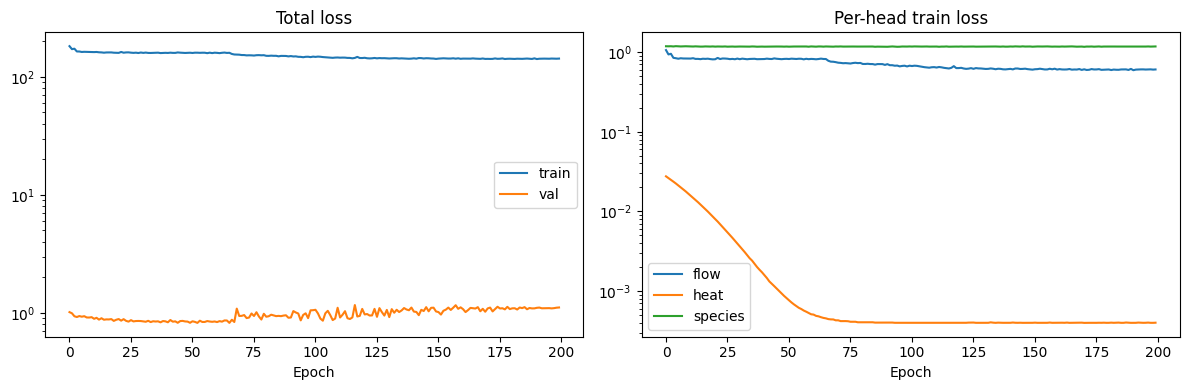

Loss curve saved.


In [39]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label='train'); axes[0].plot(val_losses, label='val')
axes[0].set_title('Total loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].set_yscale('log')

for head in ('flow', 'heat', 'species'):
    axes[1].plot(head_logs[head], label=head)
axes[1].set_title('Per-head train loss'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig(str(CKPT_DIR / 'loss_curve.png'), dpi=150)
plt.show()
print("Loss curve saved.")


In [40]:
# Verify the checkpoint loads exactly as app.py does
ck     = torch.load(final_path, map_location='cpu')
cfg_ok = ck['cfg']
norm_ok= ck['norm']

m_test = MultiHeadMGN(
    node_dim    = cfg_ok['node_input_dim'],
    edge_dim    = cfg_ok['edge_input_dim'],
    flow_out    = cfg_ok['flow_out_dim'],
    heat_out    = cfg_ok['heat_out_dim'],
    species_out = cfg_ok['species_out_dim'],
    hidden      = cfg_ok['hidden_dim'],
    n_layers    = cfg_ok['n_layers'],
)
m_test.load_state_dict(ck['model'])
m_test.eval()

# Quick forward pass on one val case
g = build_graph_tensors(val_cases[0], n_nodes=8192, k=cfg_ok['k_neighbors'], device='cpu')
with torch.no_grad():
    fp, hp, sp = m_test(g['x'], g['edge_index'], g['edge_attr'])

print("Checkpoint loads OK  ✓")
print(f"  flow    output: {fp.shape}   range [{fp.min():.3f}, {fp.max():.3f}]")
print(f"  heat    output: {hp.shape}   range [{hp.min():.3f}, {hp.max():.3f}]")
print(f"  species output: {sp.shape}   range [{sp.min():.3f}, {sp.max():.3f}]")
print(f"  norm keys:  {list(norm_ok.keys())}")
print(f"  cfg  keys:  {list(cfg_ok.keys())}")
print("\nReady to use in app.py  ✓")


Checkpoint loads OK  ✓
  flow    output: torch.Size([8192, 4])   range [-2.261, 0.689]
  heat    output: torch.Size([8192, 1])   range [-1.050, -1.050]
  species output: torch.Size([8192, 1])   range [0.046, 0.046]
  norm keys:  ['node_mean', 'node_std', 'out_mean', 'out_std', 'output_cols']
  cfg  keys:  ['hidden_dim', 'n_layers', 'k_neighbors', 'node_input_dim', 'edge_input_dim', 'flow_out_dim', 'heat_out_dim', 'species_out_dim', 'lr', 'weight_decay', 'epochs', 'save_every', 'n_train_nodes', 'n_val_nodes']

Ready to use in app.py  ✓
